In [101]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [102]:
df = pd.read_csv('House_Rent_Dataset.csv')

In [103]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,5/18/2022,2,10000.0,1100.0,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,5/13/2022,2,20000.0,NaN,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
2,5/16/2022,2,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,7/4/2022,2,10000.0,NaN,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,5/9/2022,2,7500.0,850.0,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


In [104]:
df.shape

(4746, 12)

In [105]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4746 non-null   object 
 1   BHK                4746 non-null   int64  
 2   Rent               4741 non-null   float64
 3   Size               4738 non-null   float64
 4   Floor              4746 non-null   object 
 5   Area Type          4739 non-null   object 
 6   Area Locality      4746 non-null   object 
 7   City               4746 non-null   object 
 8   Furnishing Status  4746 non-null   object 
 9   Tenant Preferred   4746 non-null   object 
 10  Bathroom           4742 non-null   float64
 11  Point of Contact   4746 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 445.1+ KB


In [106]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.741000e+03,4738.000000,4742.000000
mean,2.083860,3.502340e+04,967.936049,1.965837
std,0.832256,7.814214e+04,634.562635,0.884904
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [107]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 5
Size                 8
Floor                0
Area Type            7
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             4
Point of Contact     0
dtype: int64

In [108]:
# Fill missing values with median

for col in df.columns:
    
    if df[col].dtype != 'object':
        
        df[col].fillna(df[col].median(), inplace=True)

C:\Users\merog\AppData\Local\Temp\ipykernel_10320\1446281858.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\merog\AppData\Local\Temp\ipykernel_10320\1446281858.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [109]:
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            7
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [110]:
df.duplicated().sum()

np.int64(0)

In [111]:
df.drop_duplicates(inplace=True)

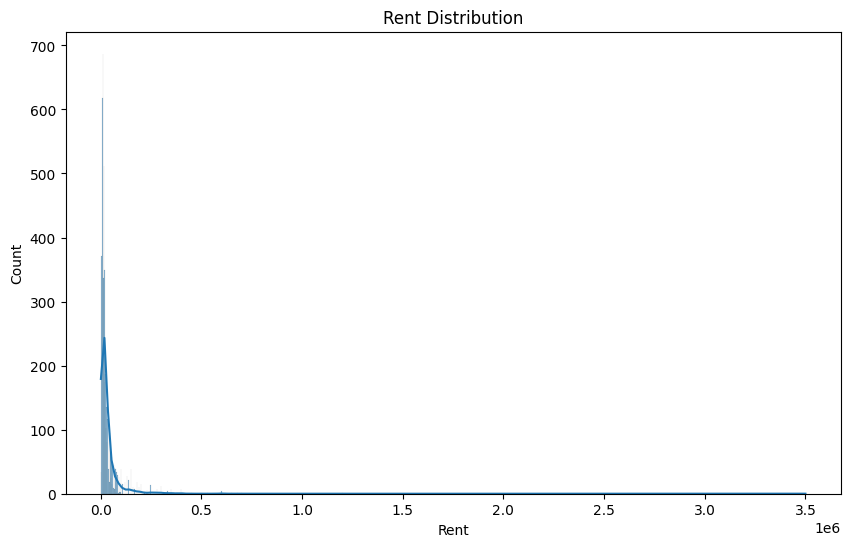

In [112]:
plt.figure(figsize=(10,6))

sns.histplot(df['Rent'], kde=True)

plt.title('Rent Distribution')

plt.show()

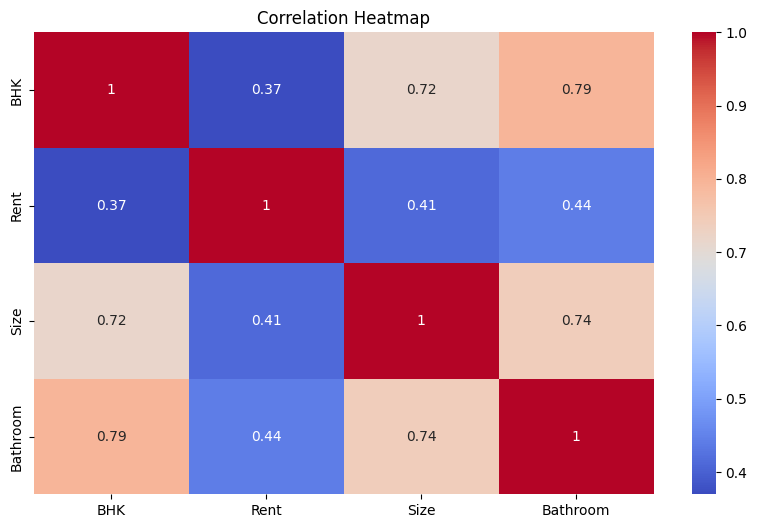

In [113]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [114]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [115]:
Q1 = df['Rent'].quantile(0.25)

Q3 = df['Rent'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[
    (df['Rent'] >= lower) &
    (df['Rent'] <= upper)
]

In [116]:
X = df.drop('Rent', axis=1)

y = df['Rent']

In [117]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,18,2,10000.0,1100.0,455,2,221,4,2,1,2.0,2
1,13,2,20000.0,850.0,14,2,1527,4,1,1,1.0,2
2,16,2,17000.0,1000.0,14,2,1760,4,1,1,1.0,2
3,75,2,10000.0,850.0,10,2,526,4,2,1,1.0,2
4,39,2,7500.0,850.0,10,1,1890,4,2,0,1.0,2


In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [119]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [120]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [121]:
y_pred_knn = knn.predict(X_test)

In [122]:
print("KNN R2 Score :")

print(r2_score(y_test, y_pred_knn))

KNN R2 Score :
0.6103230873269275


In [123]:
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [124]:
y_pred_lin = lin_reg.predict(X_test)

In [125]:
print("Linear Regression R2 Score :")

print(r2_score(y_test, y_pred_lin))

Linear Regression R2 Score :
0.5490874587675482


In [126]:
svm = SVR()

svm.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [127]:
y_pred_svm = svm.predict(X_test)

In [128]:
print("SVM R2 Score :")

print(r2_score(y_test, y_pred_svm))

SVM R2 Score :
-0.07746186611261452


In [129]:
print("MAE :")

print(mean_absolute_error(y_test, y_pred_lin))

print("MSE :")

print(mean_squared_error(y_test, y_pred_lin))

print("RMSE :")

print(np.sqrt(mean_squared_error(y_test, y_pred_lin)))

MAE :
6998.361527757451
MSE :
86308593.76782577
RMSE :
9290.241857337502


In [130]:
models = pd.DataFrame({

    'Model': [
        'KNN Regressor',
        'Linear Regression',
        'SVR'
    ],

    'R2 Score': [

        r2_score(y_test, y_pred_knn),

        r2_score(y_test, y_pred_lin),

        r2_score(y_test, y_pred_svm)
    ]
})

models

,Model,R2 Score
0,KNN Regressor,0.610323
1,Linear Regression,0.549087
2,SVR,-0.077462


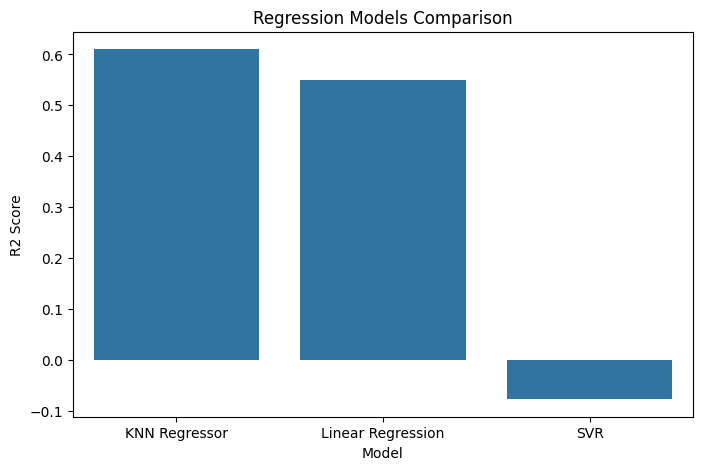

In [131]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=models
)

plt.title('Regression Models Comparison')

plt.show()